# Principal Component Analysis

demensionality reduction 기법 중 가장 대표적인 알고리즘.

* Unsupervised and Projection Based Algorithm.

variance가 큰 axis가 Task 수행에 필요한 정보를 가장 많이 가지고 있을 것이라는 가정에 기반함. 

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml(
    'mnist_784',
    as_frame=False,     # not select pandas' dataframe
    parser='liac-arff',
    )
mnist.data.shape

(70000, 784)

In [5]:
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

## PCA

In [11]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_train)
cumulated_sum = np.cumsum(
    pca.explained_variance_ratio_
)
optimal_d = np.argmax(cumulated_sum >= 0.95) + 1
print(optimal_d)

154


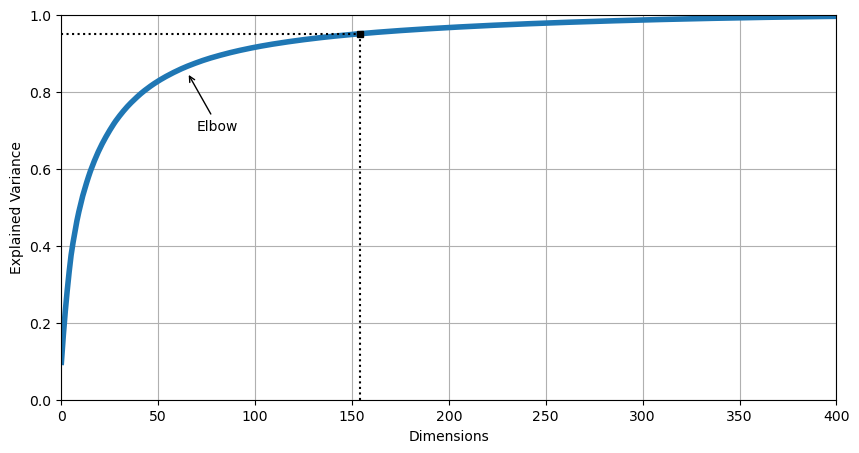

In [18]:
import matplotlib.pylab as plt

fig, axes = plt.subplots(figsize=(10,5))

axes.plot(cumulated_sum, linewidth=4)
axes.set_xlim([0,400])
axes.set_ylim([0,1.0])
axes.set_xlabel('Dimensions')
axes.set_ylabel('Explained Variance')
axes.plot([optimal_d,optimal_d], [0,0.95], 'k:')
axes.plot([0,optimal_d], [0.95,0.95], 'k:')
axes.plot(optimal_d,0.95, color='black', marker='s', markersize=5.)
axes.annotate(
    'Elbow', 
    xy=(65,0.85),
    xytext=(70,0.7),
    arrowprops=dict(arrowstyle='->')
    )
axes.grid(True)

In [19]:
optimal_pca = PCA(n_components=154)
X_reduced = optimal_pca.fit_transform(X_train)
print(X_reduced.shape)

(60000, 154)


In [56]:
print(optimal_pca.explained_variance_.shape)

(154,)


In [57]:
optimal_pca = PCA(n_components=0.95)
X_reduced = optimal_pca.fit_transform(X_train)
print(X_reduced.shape)

(60000, 154)


In [58]:
X_reconstructed = optimal_pca.inverse_transform(X_reduced)
print(X_reconstructed.shape)

(60000, 784)


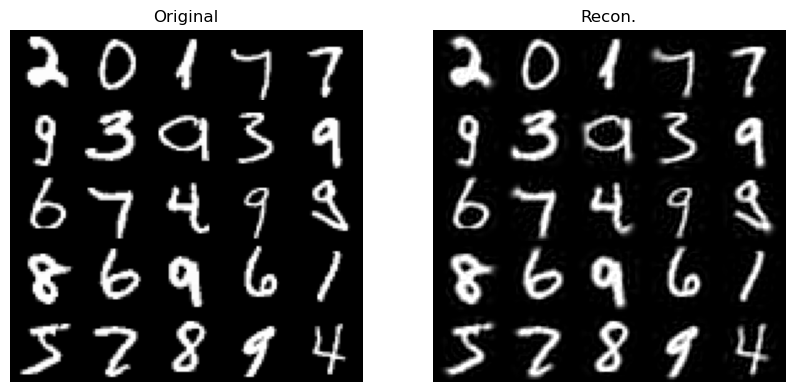

In [59]:
def comp_result(X_train, X_reconstructed):
    fig, axes = plt.subplots(
        nrows = 1,
        ncols = 2,
        figsize=(10,5)
    )
    titles = ['Original', 'Recon.']
    for idx, X in enumerate( (X_train[::2400],X_reconstructed[::2400])):
        axes[idx].set_title(titles[idx])
        for row in range(5):
            for col in range(5):
                axes[idx].imshow(
                    X[row * 5 + col].reshape(28,28),
                    cmap = 'gray',
                    vmin = 0, vmax = 255,
                    extent=(row,row+1, col, col+1)
                )
                axes[idx].axis([0,5,0,5])
                axes[idx].axis('off')
comp_result(X_train,X_reconstructed)

## Randomized PCA

(60000, 784)


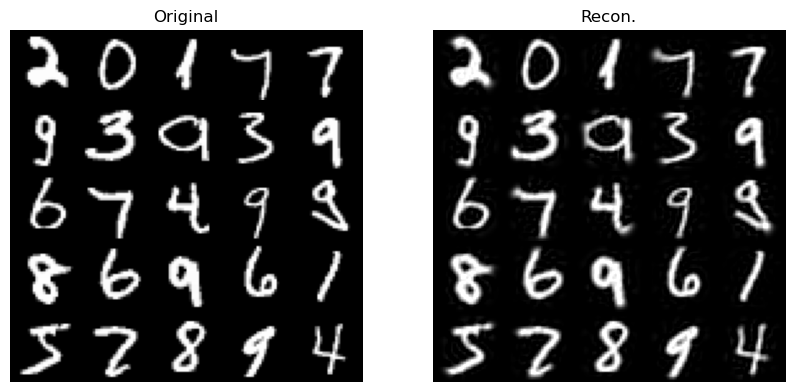

In [60]:
rnd_pca = PCA(
    # n_components=0.95,  # error
    n_components = 154,
    svd_solver = "randomized", 
    random_state = 42)
X_reduced = rnd_pca.fit_transform(X_train)

X_reconstructed = rnd_pca.inverse_transform(X_reduced)
print(X_reconstructed.shape)

comp_result(X_train,X_reconstructed)

## IncrementalPCA

(60000, 784)


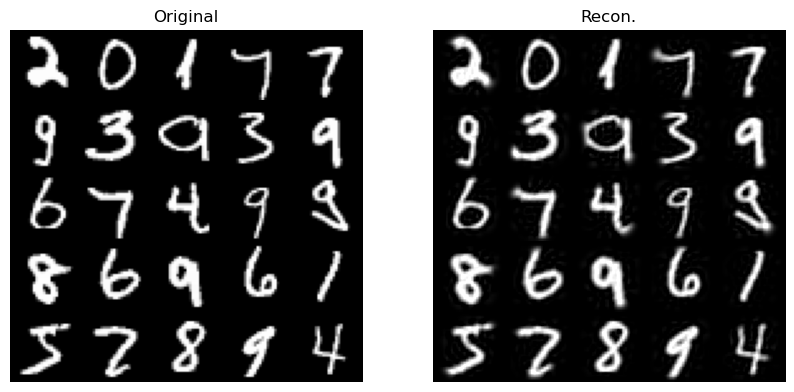

In [61]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)
X_reconstructed = inc_pca.inverse_transform(X_reduced)
print(X_reconstructed.shape)

comp_result(X_train,X_reconstructed)


## NumPy's `memmap`

Using NumPy's `memmap` class – a memory-map to an array stored in a binary file on disk.

Let's create the `memmap` instance, copy the MNIST training set into it, and call flush() which ensures that any data still in cache is saved to disk. This would typically be done by a first program:

In [62]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train  # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

In [63]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)